# Inwiefern besteht ein Zusammenhang zwischen der Brutto CO2 Einspeisung, Trockenheit, Pflanzenmenge und der Bodentemperatur in Deutschland?

### bezogen auf die Hitzewelle 2018 in Deutschland

Was brauchen wir?

Erstmal: GPP Vergleich mit Trockenheit. Dafür: zwei Karten. Graph (Durschnittliche Trockenheit in Deutschland + Durschnittlicher GPP in Deutschland)

Plan::: Daten für GPP, Trockenheit, Bodentemperatur download. => auf gleiches Raster interpolieren. => alle drei auf nem Line Graph plotten

- CO2: CLMS_GPP_GLOBAL_300M_10DAILY_V2 2013-present
- Feuchtigkeit: CLMS_SWI_EUROPE_1KM_DAILY_V1 2014-present
- Temperatur: CLMS_LST_TCI_GLOBAL_3KM_10DAILY_V3 2016-present

=> 2016-present?

In [2]:
GPP_ID = "CLMS_GPP_GLOBAL_300M_10DAILY_V2"
SWI_ID = "CLMS_SWI_EUROPE_1KM_DAILY_V1"
LST_ID = "CLMS_LST_TCI_GLOBAL_3KM_10DAILY_V3"

In [3]:
spatial_extent = {
    'west': 5,
    'south': 46,
    'east': 15.5,
    'north': 56,
}

In [4]:
temporal_extent = ["2018-01-01", "2025-12-31"]

Imports

In [5]:
import numpy as np
import folium
import geopandas as gpd
import json
import leafmap
import math
import matplotlib.pyplot as plt
import os
import openeo
import pyproj
import rasterio

import rasterio as rio
from rasterio.plot import show
from shapely.geometry import Polygon
from datetime import datetime

Authentification

In [6]:
from openeo.rest.auth.config import RefreshTokenStore

connection = openeo.connect("openeofed.dataspace.copernicus.eu")
connection.authenticate_oidc()
print(connection.describe_account())

Authenticated using refresh token.
{'info': {'oidc_userinfo': {'email': 'moritz.fechte@icloud.com', 'email_verified': True, 'family_name': 'Fe', 'given_name': 'Mo', 'name': 'Mo Fe', 'preferred_username': 'moritz.fechte@icloud.com', 'sub': '01b88e4b-35a5-4da2-8e10-edc6a6ce408f'}}, 'name': 'Mo Fe', 'user_id': '01b88e4b-35a5-4da2-8e10-edc6a6ce408f'}


### Datacube Preprocessing Methoden

Deutschland ausschneiden (germany.geojson Datei notwendig)

In [7]:
def get_german_geometry():
    germany = gpd.read_file("germany.geojson")
    return germany.geometry.iloc[0].__geo_interface__

def mask_germany(datacube, german_geometry):
    return datacube.mask_polygon(
        german_geometry,
        srs="EPSG:4326"
    )

Zeit auf 10 Tage Intervall reduzieren

In [8]:
def reduce_to_decad(datacube):
    return datacube.aggregate_temporal_period(
        period="dekad",
        reducer="mean"
    )

Auflösung auf 1km reduzieren (resamplen)

In [9]:
def align_to_other_cube(grid_providing_cube, cube):
    return cube.resample_cube_spatial(
        target=grid_providing_cube,
        method="average"
    )

In [10]:
def get_mean(datacube, german_geometry):
    return datacube.aggregate_spatial(
        geometries=german_geometry,
        reducer='mean',
    )

### GPP Download

In [11]:
def load_datacubes():
    gpp = connection.load_collection(
        GPP_ID,
        spatial_extent=spatial_extent,
        temporal_extent = temporal_extent,
        bands=["gpp"],
    )

    ssm = connection.load_collection(
        SWI_ID,
        spatial_extent=spatial_extent,
        temporal_extent=temporal_extent,
        bands=["swi020"],
    )

    lst = connection.load_collection(
        LST_ID,
        spatial_extent=spatial_extent,
        temporal_extent=temporal_extent,
        bands=["tci_median"],
    )

    return gpp, ssm, lst

In [18]:
# preprocessing execution
def preprocess_maps(gpp, ssm, lst, german_geometry):
    # select bands
    gpp = gpp.band('gpp')
    swi = ssm.band('swi020')
    lst = lst.band('tci_median')

    gpp = reduce_to_decad(gpp)
    gpp = align_to_other_cube(swi, gpp)
    gpp = mask_germany(gpp, german_geometry)

    swi = reduce_to_decad(swi)
    swi = mask_germany(swi, german_geometry)

    lst = reduce_to_decad(lst)
    #lst = align_to_other_cube(swi, lst)
    lst = mask_germany(lst, german_geometry)

    return gpp, swi, lst

def download_means(gpp, swi, lst, german_geometry):
    print('downloading gpp')
    gpp_means = get_mean(gpp, german_geometry).execute()
    with open('means/gppmeans.json', "w") as file:
        json.dump(gpp_means, file, indent=4)
    print('downloading swi')
    swi_means = get_mean(swi, german_geometry).execute()
    with open('means/swimeans.json', "w") as file:
        json.dump(swi_means, file, indent=4)
    print('downloading lst')
    lst_means = get_mean(lst, german_geometry).execute()
    with open('means/lstmeans.json', "w") as file:
        json.dump(lst_means, file, indent=4)
    print('done')

    return gpp_means, swi_means, lst_means



# gpp.download('gpp.tif')

computing und downloaden

In [19]:
gpp, swi, lst = load_datacubes()
german_geometry = get_german_geometry()
gpp, swi, lst = preprocess_maps(gpp, swi, lst, german_geometry)
gpp_means, swi_means, lst_means = download_means(gpp, swi, lst, german_geometry)

downloading gpp
downloading swi
downloading lst
done


### Diagnose: Datenverfügbarkeit & Geometrie prüfen

Bevor wir Differenzenkarten bauen: prüfen, ob `germany.geojson` wirklich ganz Deutschland als eine Geometrie liefert, 
und ob alle drei Collections tatsächlich Daten für die Baseline-Fenster (Juni 2018/2019/2020) und das aktuelle Fenster (Juni 2026) haben.

In [20]:
germany_gdf = gpd.read_file("germany.geojson")
print(f"germany.geojson: {len(germany_gdf)} Feature(s), geometry type: {germany_gdf.geometry.iloc[0].geom_type}")
if len(germany_gdf) > 1:
    print("WARNUNG: mehr als 1 Feature – .iloc[0] nimmt evtl. nur ein Bundesland statt ganz Deutschland!")

for cid, name in [(GPP_ID, "GPP"), (SWI_ID, "SWI"), (LST_ID, "LST")]:
    meta = connection.describe_collection(cid)
    temporal = meta.get("extent", {}).get("temporal", {}).get("interval")
    print(f"{name} ({cid}) temporal extent: {temporal}")


germany.geojson: 1 Feature(s), geometry type: MultiPolygon
GPP (CLMS_GPP_GLOBAL_300M_10DAILY_V2) temporal extent: [['2013-11-01T00:00:00Z', None]]
SWI (CLMS_SWI_EUROPE_1KM_DAILY_V1) temporal extent: [['2014-12-31T12:00:01Z', '2025-07-12T12:00:00Z']]
LST (CLMS_LST_TCI_GLOBAL_3KM_10DAILY_V3) temporal extent: [['2018-01-01T00:00:00Z', None]]


import json means

In [21]:
with open('means/gppmeans.json', 'r') as file:
    gpp_means = json.load(file)
with open('means/swimeans.json', 'r') as file:
    swi_means = json.load(file)
with open('means/lstmeans.json', 'r') as file:
    lst_means = json.load(file)

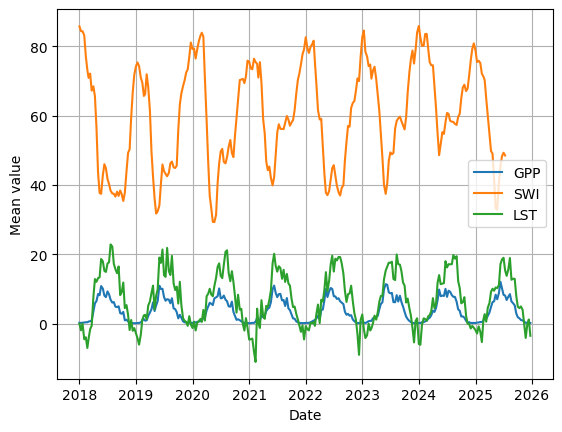

In [26]:
def extract_data(data): 
    dates = [datetime.fromisoformat(date.replace("Z", "+00:00")) for date in data] 
    values = [value[0][0] for value in data.values()] 
    return dates, values 

gpp_dates, gpp_values = extract_data(gpp_means) 
swi_dates, swi_values = extract_data(swi_means) 
lst_dates, lst_values = extract_data(lst_means)

#converting lst temp from K into C
for i in range(len(lst_values)):
    lst_values[i] -= 273.15

plt.plot(gpp_dates, gpp_values, label="GPP") 
plt.plot(swi_dates, swi_values, label="SWI") 
plt.plot(lst_dates, lst_values, label="LST") 
plt.xlabel("Date") 
plt.ylabel("Mean value") 
plt.legend() 
plt.grid() 
plt.show()

Man merkt den starken Einfluss der Jahreszeiten, welcher die Veränderungen zwischen den Jahren überdeckt

=> Jahresdurchschnittswerte Vergleichen

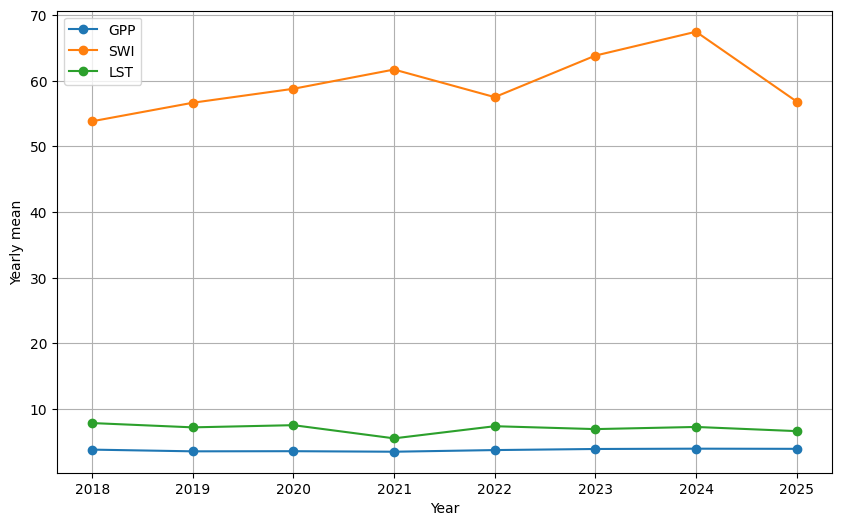

In [29]:
def yearly_averages(dates, values):
    years = np.array([date.year for date in dates])
    values = np.array(values, dtype=float)

    unique_years = np.unique(years)
    averages = [
        np.nanmean(values[years == year])
        for year in unique_years
    ]

    return unique_years, averages


gpp_years, gpp_yearly = yearly_averages(gpp_dates, gpp_values)
swi_years, swi_yearly = yearly_averages(swi_dates, swi_values)
lst_years, lst_yearly = yearly_averages(lst_dates, lst_values)


plt.figure(figsize=(10, 6))

plt.plot(gpp_years, gpp_yearly, marker="o", label="GPP")
plt.plot(swi_years, swi_yearly, marker="o", label="SWI")
plt.plot(lst_years, lst_yearly, marker="o", label="LST")

plt.xlabel("Year")
plt.ylabel("Yearly mean")
plt.xticks(gpp_years)
plt.legend()
plt.grid()
plt.show()

### Pläne
- Differenzenkarte 1 Juli 2018-2020 vs 1 Juli 2026 für GPP, SWI, LTS
- (Splitmap)
- Kartenvideo zeigt Veränderung
- Scatter plot GPP vs SWI, GPP vs LTS
- Plot von 2018 - 2025 averages mit GPP, SWI und LTS

### Differenzenkarte

downloading gpp difference map
downloading swi difference map
downloading lst difference map
GPP Differenzenkarte


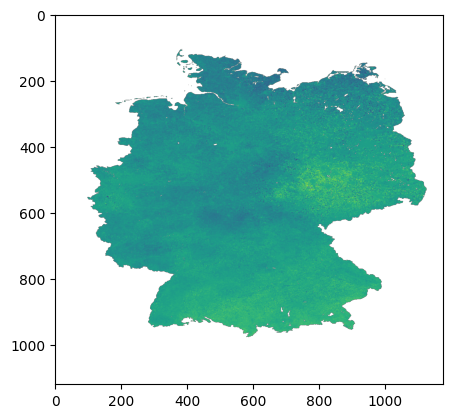

SWI Differenzenkarte


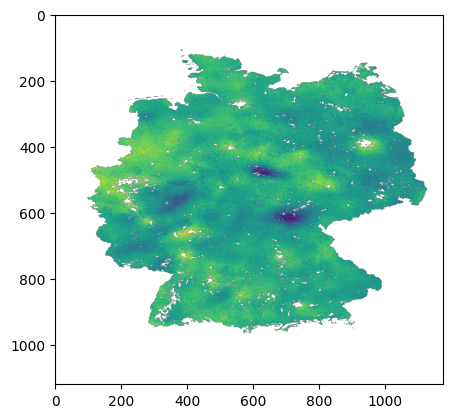

LST Differenzenkarte


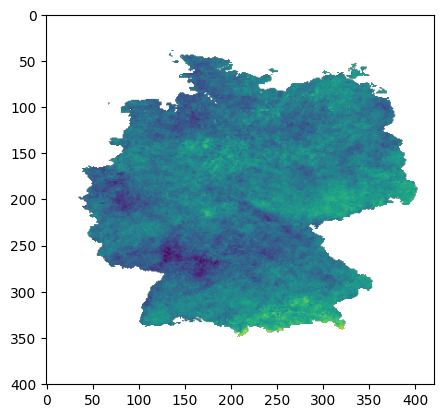

<Axes: >

In [31]:
def average_baseline(datacube):
    intervals = [
        ["2018-06-01", "2018-06-11"],
        ["2019-06-01", "2019-06-11"],
        ["2020-06-01", "2020-06-11"],
    ]

    baseline = datacube.aggregate_temporal(
        intervals=intervals,
        reducer="mean"
    )

    return baseline.reduce_dimension(
        dimension="t",
        reducer="mean"
    )

def download_and_read(datacube, filepath):
    """Downloads a single-timestep cube to disk and reads it back as a
    float array (nodata -> NaN), so we can work with real numbers
    instead of the lazy process graph."""
    datacube.download(filepath)
    with rio.open(filepath) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            arr = np.where(arr == nodata, np.nan, arr)
        profile = src.profile
    return arr, profile

def print_stats(label, arr):
    valid = arr[~np.isnan(arr)]
    if valid.size == 0:
        print(f"{label}: EMPTY / all nodata! shape={arr.shape}")
    else:
        print(f"{label}: shape={arr.shape}, valid={valid.size}/{arr.size}, "
              f"min={valid.min():.3f}, max={valid.max():.3f}, mean={valid.mean():.3f}")

def download_difference(datacube, filepath, label):
    baseline = average_baseline(datacube)
    current = datacube.filter_temporal(
        ["2025-06-01", "2025-06-11"]
    ).reduce_dimension(
        dimension="t",
        reducer="mean"
    )

    os.makedirs('debug', exist_ok=True)
    baseline_arr, baseline_profile = download_and_read(baseline, f"debug/{label}_baseline.tif")
    current_arr, current_profile = download_and_read(current, f"debug/{label}_current.tif")

    print_stats(f"{label} baseline", baseline_arr)
    print_stats(f"{label} current", current_arr)

    if baseline_arr.shape != current_arr.shape:
        print(f"WARNUNG: {label} baseline {baseline_arr.shape} und current "
              f"{current_arr.shape} haben unterschiedliche Shapes! Differenz wird trotzdem versucht.")

    # difference computed client-side, not via openEO cube subtraction
    difference_arr = current_arr - baseline_arr
    print_stats(f"{label} difference", difference_arr)

    os.makedirs(os.path.dirname(filepath), exist_ok=True)
    out_profile = current_profile.copy()
    out_profile.update(dtype="float32", nodata=np.nan, count=1)
    with rio.open(filepath, "w", **out_profile) as dst:
        dst.write(difference_arr.astype("float32"), 1)

    return difference_arr


os.makedirs('difference_maps', exist_ok=True)

print('downloading gpp difference map')
#gpp_difference_map = download_difference(gpp, 'difference_maps/gpp.tif', 'gpp')
print('downloading swi difference map')
#swi_difference_map = download_difference(swi, 'difference_maps/swi.tif', 'swi')
print('downloading lst difference map')
#lst_difference_map = download_difference(lst, 'difference_maps/lst.tif', 'lst')

print('GPP Differenzenkarte')
show(rio.open('difference_maps/gpp.tif').read())
print('SWI Differenzenkarte')
show(rio.open('difference_maps/swi.tif').read())
print('LST Differenzenkarte')
show(rio.open('difference_maps/lst.tif').read())

Man kommt nicht weit, wenn man 10min pro Bild download warten muss :(